# Variational Autoencoders in PyTorch

**Generative and Deep Learning** (2025/2026)

*Riccardo Massidda* – riccardo.massidda@di.unipi.it

A Variational Autoencoder (VAE) is a latent-variable generative model that pairs a probabilistic encoder $q_\phi(\mathbf{z}\mid\mathbf{x})$ with a probabilistic decoder $p_\theta(\mathbf{x}\mid\mathbf{z})$. The encoder maps an observation $\mathbf{x}$ to the parameters of an approximate posterior over latent codes $\mathbf{z}$. Samples of the input distribution $p(\mathbf{x})$ are then drawn from the latent distribution $p(\mathbf{z})$ via the reparameterization trick and the decoder. The model is trained by maximizing the Evidence Lower Bound (ELBO) on the marginal log-likelihood:

$$
  \log p_\theta(\mathbf{x})
  \;\geq\;
  \mathcal{L}(\theta,\phi;\mathbf{x})
  \;=\;
  \underbrace{\mathbb{E}_{q_\phi(\mathbf{z}\mid\mathbf{x})}\!\bigl[\log p_\theta(\mathbf{x}\mid\mathbf{z})\bigr]}_{\text{reconstruction}}
  \;-\;
  \underbrace{\text{KL}\!\bigl(q_\phi(\mathbf{z}\mid\mathbf{x})\;\|\;p(\mathbf{z})\bigr)}_{\text{regularization}}\,.
$$

The first term encourages faithful reconstruction. The second term, the Kullback–Leibler divergence between the approximate posterior and the prior $p(\mathbf{z})=\mathcal{N}(\mathbf{0},\mathbf{I})$, regularizes the latent space so that it remains smooth and allows for meaningful sampling and interpolation.

When the prior and approximate posterior are both Gaussian, the KL term has a convenient closed-form expression. Letting $q_\phi(\mathbf{z}\mid\mathbf{x})=\mathcal{N}(\boldsymbol{\mu}(\mathbf{x}),\operatorname{diag}(\boldsymbol{\sigma}(\mathbf{x})^2))$ and $p(\mathbf{z})=\mathcal{N}(\mathbf{0},\mathbf{I})$ with latent dimension $d$:

$$
  \text{KL}\!\bigl(q_\phi(\mathbf{z}\mid\mathbf{x})\;\|\;p(\mathbf{z})\bigr)
  \;=\;
  -\frac{1}{2}\sum_{j=1}^{d}\Bigl(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\Bigr)\,.
$$

In practice, these two objectives are in tension.  Pushing too hard on the KL term can lead to *posterior collapse*: the encoder ignores the input and outputs the prior for every $\mathbf{x}$, leaving all the modeling burden to the decoder.  Conversely, underweighting the KL term yields good reconstructions but a poorly structured latent space from which sampling produces incoherent outputs.

This notebook provides you with the necessary code to implement a standard VAE and four extensions:

1. **Standard VAE** (baseline)
2. **β-VAE** — disentangled representations via KL re-weighting
3. **Conditional VAE (CVAE)** — class-conditioned generation
4. **KL Annealing / Cyclical Annealing** — training schedule to prevent posterior collapse
5. **MMD-VAE (InfoVAE)** — MMD replaces KL divergence

Overall, we provide you three datasets to test your implementation.
- **Simulated**: 2D mixture of 3, rendered as 32x32 grayscale images.
- **Small-MNIST**: 4-digits subset (0, 1, 2, 3).
- **MNIST**: Full 10-digits dataset at original 28x28 resolution.

⚠️ All of the groups are expected to solve the Standard VAE baseline, then choose **one** of the possible extensions.

## Imports and Data

Choose the dataset to be used for the notebook execution.
For each dataset, we define three constants that you can use for your implementation. The size of each image (`IMG_SIZE`), the number of classes in the dataset (`NUM_CLASSES`), and the label of the classes (`CLASSES`). We always assume the input data to be square images.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import requests

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


How do I train a model? Short reminder from the PyTorch lecture. First, define your model as a `nn.Module`. Then, train using an optimizer and a loss function.

```python
class MyModel(nn.Module):
  pass

def my_loss(y, y_hat):
  return ((y - y_hat) ** 2).mean()

def train_net(model, train_loader, epochs, lr) -> dict:
  optimizer = torch.optim.SGD(model.parameters(), lr=lr)
  history = {"MSE": []}

  for epoch in range(epochs):
    # Train
    net_hat.train()
    total_mse = 0.0
    for x, y in train_loader:
        optimizer.zero_grad()
        y_hat = net_hat(x)
        loss = my_loss(y_hat, y)
        loss.backward()
        optimizer.step()
        total_mse += loss.item()

    avg_mse = total_mse / len(train_loader)
    history["MSE"].append(avg_mse)

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | Train: {avg_mse:.4f}")
  return history

net_hat = MyModel()
train_loader: DataLoader = None
net_history = train_net(net_hat, train_loader, epochs=50, lr=1e-3)
```



### Dataset Loader and Utilities

Do not edit the following cells. They are used to load data and visualize different aspects of your implementation. In particular,



In [21]:
DATASET = "MNIST" # (Synthetic, Small-MNIST, MNIST)

if DATASET == "Synthetic":
    IMG_SIZE = 28
    NUM_CLASSES = 4
    CLASSES = ['Top-Left', 'Top-Right', 'Bottom-Left', 'Bottom-Right']
elif DATASET == "Small-MNIST":
    IMG_SIZE = 28
    NUM_CLASSES = 4
    CLASSES= list(range(NUM_CLASSES))
elif DATASET == "MNIST":
    IMG_SIZE = 28
    NUM_CLASSES = 10
    CLASSES= list(range(NUM_CLASSES))
else:
    raise ValueError("Unknown dataset.")

BATCH_SIZE = 128
INPUT_DIM = IMG_SIZE * IMG_SIZE

print(f"Dataset: {DATASET} ({INPUT_DIM}→{NUM_CLASSES}) batch size {BATCH_SIZE}")

Dataset: MNIST (784→10) batch size 128


In [22]:
def get_synthetic_data(n_samples=10000, img_size=10) -> tuple[torch.Tensor, torch.Tensor]:
    images = np.zeros((n_samples, img_size, img_size), dtype=np.float32)
    labels = np.zeros(n_samples, dtype=np.int64)

    radius = max(1, img_size // 8)
    mid = img_size / 2

    ys, xs = np.mgrid[0:img_size, 0:img_size]

    for i in range(n_samples):
        cx = np.random.uniform(radius, img_size - radius - 1)
        cy = np.random.uniform(radius, img_size - radius - 1)

        images[i] = ((xs - cx) ** 2 + (ys - cy) ** 2 <= radius ** 2).astype(np.float32)

        # Quadrant label based on center position
        # 0: top-left, 1: top-right, 2: bottom-left, 3: bottom-right
        labels[i] = (cx >= mid) + 2 * (cy >= mid)

    return torch.from_numpy(images), torch.from_numpy(labels)


if DATASET == "Synthetic":
    x_train, y_train = get_synthetic_data(8000, img_size=IMG_SIZE)
    x_test, y_test = get_synthetic_data(2000, img_size=IMG_SIZE)
    train_dataset = TensorDataset(x_train.view(-1, 1, IMG_SIZE, IMG_SIZE), y_train)
    test_dataset = TensorDataset(x_test.view(-1, 1, IMG_SIZE, IMG_SIZE), y_test)
else:
    # resize and toTensor transformations
    transforms_list = []
    if IMG_SIZE != 28:
      transforms_list.append(transforms.Resize(IMG_SIZE))
    transforms_list.append(transforms.ToTensor())
    transform = transforms.Compose(transforms_list)

    # MNIST dataset
    full_train = datasets.MNIST(
        root=". /data", train=True, download=True, transform=transform)
    full_test = datasets.MNIST(
        root=". /data", train=False, download=True, transform=transform)

    def filter_digits(dataset, digits):
        digit_set = set(digits)
        indices = [i for i, (_, y) in enumerate(dataset) if y in digit_set]
        return Subset(dataset, indices)

    train_dataset = filter_digits(full_train, CLASSES)
    test_dataset = filter_digits(full_test, CLASSES)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train set size: {len(train_dataset)} ({len(train_loader)} batches)")
print(f"Test set size: {len(test_dataset)} ({len(test_loader)} batches)")

Train set size: 60000 (469 batches)
Test set size: 10000 (79 batches)


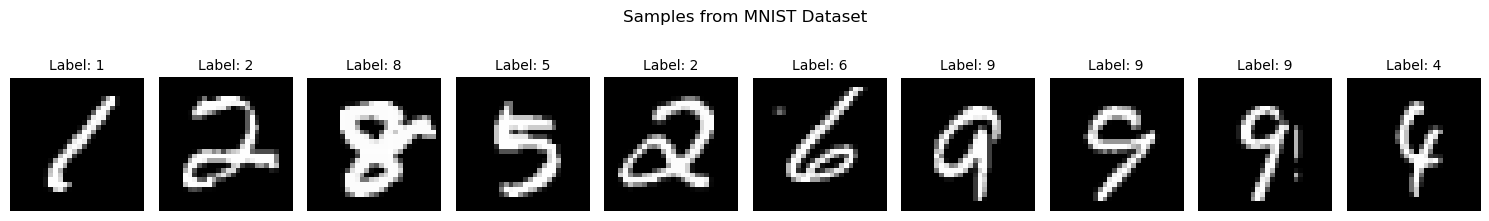

In [23]:
def visualize_dataset_samples(data_loader, n=10):
    """Visualize a few samples from the current dataset with their labels."""
    batch_x, batch_y = next(iter(data_loader))
    n = min(n, batch_x.size(0))

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))
    for i in range(n):
        img = batch_x[i].squeeze().cpu().numpy()
        label = CLASSES[batch_y[i].item()]
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"Label: {label}", fontsize=10)
        axes[i].axis("off")

    plt.suptitle(f"Samples from {DATASET} Dataset", fontsize=12, y=1.1)
    plt.tight_layout()
    plt.show()

visualize_dataset_samples(train_loader, n=10)

In [24]:
def show_reconstructions(
    model, data_loader, n=10, title="Reconstructions"
):
    """Show original images and their reconstructions."""
    model.eval()
    with torch.no_grad():
        x, y = next(iter(data_loader))
        x = x.to(device)[:n]
        y = y.to(device)[:n]
        recon = model(x)[0]

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("$x$", fontsize=10)
    axes[1, 0].set_title("$VAE(x)$", fontsize=10)
    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def show_samples(model, n: int = 10, title: str = "Samples"):
    """Generate and display samples from the prior. Supports VAE and CVAE."""
    model.eval()
    with torch.no_grad():
        samples = model.sample(n).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.5))
    for i in range(n):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")

    fig.suptitle(title, fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()


def plot_losses(loss_dict: dict, title="Training Loss"):
    """Plot training loss curve with components if available."""
    plt.figure(figsize=(8, 4))
    for label, values in loss_dict.items():
        plt.plot(values, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def show_latent_space(model, data_loader, title="Latent Space"):
    """Visualize the first two latent dimensions, colored by digit class."""
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            zs.append(mu[:, :2].cpu())
            ys.append(y)
    zs = torch.cat(zs)
    ys = torch.cat(ys)
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        zs[:, 0], zs[:, 1], c=ys, cmap="tab10", s=1, alpha=0.5, vmin=0, vmax=9)
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.tight_layout()
    plt.show()


## 1. Standard VAE

The baseline model maximizes the ELBO:

$$\mathcal{L}(\theta,\phi;\mathbf{x}) = \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})}[\log p_\theta(\mathbf{x}|\mathbf{z})] - \mathrm{KL}(q_\phi(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z}))$$

Using the following stub, implement the encoder and decoder models. Feel free to change the parameters in the constructor of the Encoder/Decoder, but implement the necessary methods to use the utility functions.

In [25]:
import numpy as np

class Encoder(nn.Module):
    def __init__(self, hidden_channels: int, latent_dim: int) -> None:
        super().__init__()
        self.cv1 = nn.Conv2d(1, hidden_channels, 3)                     
        self.pool = nn.MaxPool2d(2)                                     
        self.cv2 = nn.Conv2d(hidden_channels, 2 * hidden_channels, 3)   
        self.fc_mu = nn.Linear(2 * hidden_channels * 5 * 5, latent_dim) 
        self.fc_logvar = nn.Linear(2 * hidden_channels * 5 * 5, latent_dim) 

    def forward(self, x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
        conv1 = F.relu(self.cv1(x))             # (batch, 1, 28, 28) -> (batch, hidden_channels, 26, 26)
        pool1 = self.pool(conv1)                # (batch, hidden_channels, 26, 26) → (batch, hidden_channels, 13, 13)
        conv2 = F.relu(self.cv2(pool1))         # (batch, hidden_channels, 13, 13) → (batch, 2*hidden_channels, 11, 11)
        pool2 = self.pool(conv2)                # (batch, 2*hidden_channels, 11, 11) → (batch, 2*hidden_channels, 5, 5)
        flat = pool2.view(pool2.size(0), -1)    # (batch, 2*hidden_channels, 5, 5) → (batch, 2*hidden_channels*5*5)
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, hidden_channels: int, latent_dim: int) -> None:
        super().__init__()
        self.hidden_channels = hidden_channels
        self.fc = nn.Linear(latent_dim, 2 * hidden_channels * 5 * 5)
        self.cvt1 = nn.ConvTranspose2d(2 * hidden_channels, hidden_channels, 3, stride=2)
        self.cvt2 = nn.ConvTranspose2d(hidden_channels, 1, 3, stride=2)
        self.up = nn.Upsample(size=(28, 28))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        expand = self.fc(x)                                                     # (batch, latent_dim) → (batch, 2*hidden*5*5)
        resh = expand.view(expand.size(0), 2 * self.hidden_channels, 5 , 5)     # (batch, 2*hidden*5*5) → (batch, 2*hidden, 5, 5) 
        convt1 = F.relu(self.cvt1(resh))                                        # (batch, 2*hidden, 5, 5) → (batch, hidden, 11, 11)
        convt2 = self.cvt2(convt1)                                              # (batch, hidden, 11, 11) → (batch, 1, 23, 23)
        out = self.up(convt2)                                                   # (batch, 1, 23, 23) → (batch, 1, 28, 28)
        return torch.sigmoid(out)                                               # (batch, 1, 28, 28)

class VAE(nn.Module):
    def __init__(
        self,
        hidden_dim: int,
        latent_dim: int
      ):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(hidden_dim, latent_dim)
        self.decoder = Decoder(hidden_dim, latent_dim)

    def sample(self, num_samples: int):
        noise = torch.normal(0, 1, size=(num_samples, self.latent_dim)).to(device)
        return self.decoder.forward(noise)

    def forward(self, x):
        # Should loop over all images in dataset x
        mu, logvar = self.encoder.forward(x)
        sigma = torch.exp(logvar / 2)
        eps = torch.normal(0, 1, size=mu.shape).to(device)
        z = mu + sigma * eps
        x_hat = self.decoder.forward(z)
        return x_hat, mu, logvar

In [26]:
def train_vae(model, train_loader, epochs, lr) -> dict:
    """Should return a dictionary of the history of the loss, the reconstruction, and KL"""
    history = {"Total": [], "Rec": [], "KL": []}

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        batch_history = {"Total": [], "Rec": [], "KL": []}
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            x_hat, mu, logvar = model(x)
            rec = reconstruction_loss(x, x_hat)
            kl = kl_divergence(mu, logvar)
            loss = rec + kl
            loss.backward()
            optimizer.step()
            batch_history["Total"].append(loss.item())
            batch_history["Rec"].append(rec.item())
            batch_history["KL"].append(kl.item())

        history["Total"].append(sum(batch_history["Total"]) / len(batch_history["Total"]))
        history["Rec"].append(sum(batch_history["Rec"]) / len(batch_history["Rec"]))
        history["KL"].append(sum(batch_history["KL"]) / len(batch_history["KL"]))

        if epoch % 10 == 0 or epoch == epochs-1:
            print(f"Epoch {epoch:3d} | Total: {history['Total'][-1]:.4f} | Rec: {history['Rec'][-1]:.4f} | KL: {history['KL'][-1]:.4f}")
    
    return history

def reconstruction_loss(x, x_hat):
    """Binary cross-entropy loss between original and reconstructed images."""
    return F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)

def kl_divergence(mu, logvar):
    """KL divergence between the latent distribution and the standard normal prior."""
    return -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp()) / mu.size(0)

if DATASET == "Synthetic":
    print("Training Standard VAE on Simulated data...")
    latent_dim, hidden_dim, epochs, lr = 2, 16, 50, 1e-3
elif DATASET == "Small-MNIST":
    print("Training Standard VAE on Small-MNIST...")
    latent_dim, hidden_dim, epochs, lr = 2, 16, 50, 1e-3
else: # MNIST
    print("Training Standard VAE on full MNIST...")
    latent_dim, hidden_dim, epochs, lr = 2, 16, 50, 1e-3

vae = VAE(hidden_dim=hidden_dim, latent_dim=latent_dim)
vae = vae.to(device)
vae_history = train_vae(vae, train_loader, epochs=epochs, lr=lr)

Training Standard VAE on full MNIST...
Epoch   0 | Total: 232.0618 | Rec: 221.7342 | KL: 10.3277
Epoch  10 | Total: 167.8521 | Rec: 163.0144 | KL: 4.8377
Epoch  20 | Total: 163.4514 | Rec: 158.3072 | KL: 5.1442
Epoch  30 | Total: 162.1167 | Rec: 156.8440 | KL: 5.2726
Epoch  40 | Total: 161.2980 | Rec: 155.9449 | KL: 5.3531
Epoch  49 | Total: 160.8137 | Rec: 155.3945 | KL: 5.4192


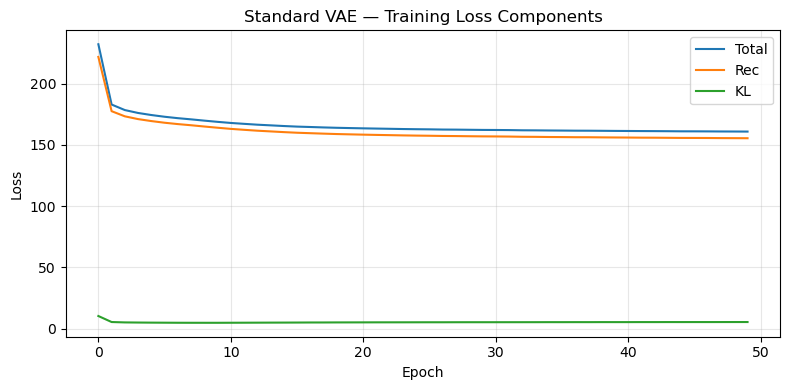

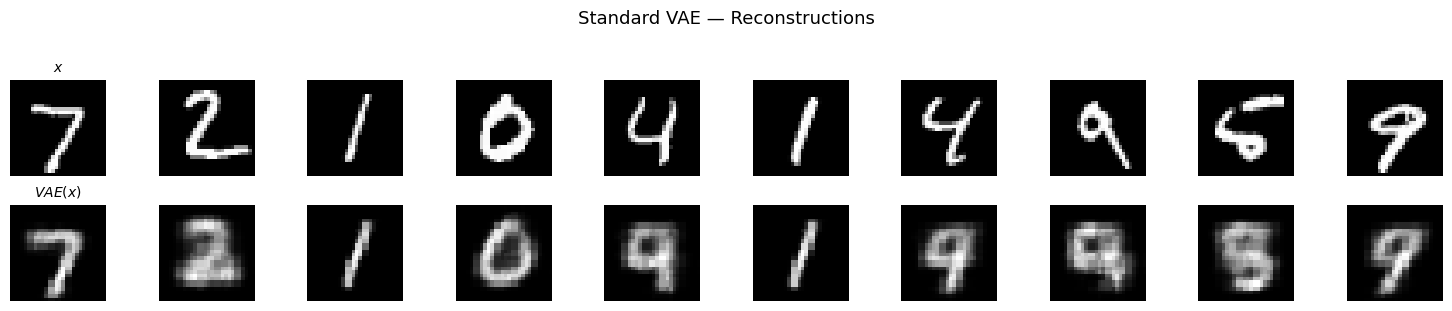

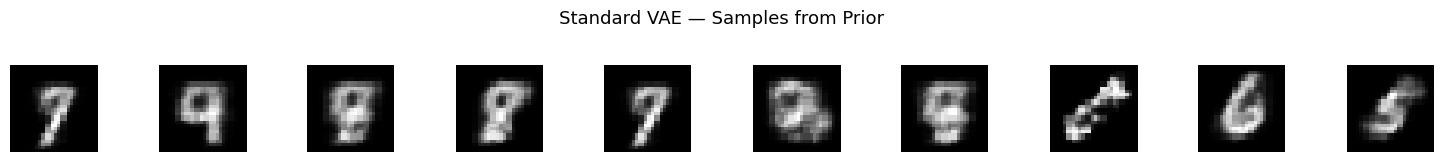

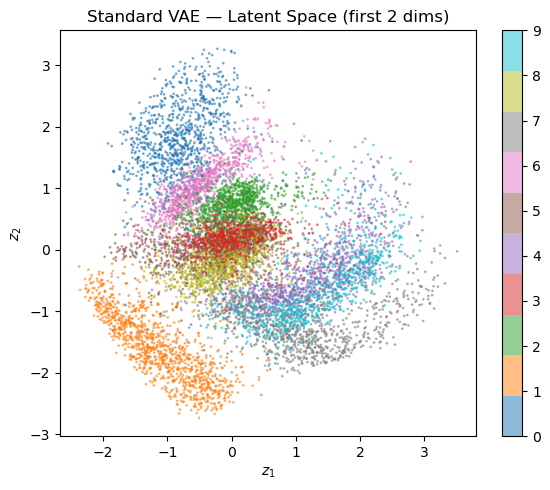

In [27]:
plot_losses(vae_history, "Standard VAE — Training Loss Components")
show_reconstructions(vae, test_loader, title="Standard VAE — Reconstructions")
show_samples(vae, title="Standard VAE — Samples from Prior")
show_latent_space(vae, test_loader, title="Standard VAE — Latent Space (first 2 dims)")

---
## 2. β-VAE

The $\beta$-VAE introduces a single hyperparameter $\beta$ that re-weights the KL term in the ELBO:

$$
\mathcal{L}_\beta(\theta,\phi;\mathbf{x})
\;=\;
\mathbb{E}_{q_\phi(\mathbf{z}\mid\mathbf{x})}\!\bigl[\log p_\theta(\mathbf{x}\mid\mathbf{z})\bigr]
\;-\;
\beta\;\mathrm{KL}\!\bigl(q_\phi(\mathbf{z}\mid\mathbf{x})\;\|\;p(\mathbf{z})\bigr)
$$

When $\beta > 1$, the model is pushed toward learning *disentangled* latent representations — representations in which individual latent dimensions correspond to independent generative factors of variation in the data (e.g., shape, color, orientation). The trade-off is that reconstruction quality decreases as $\beta$ grows, since more capacity is devoted to matching the prior.

**What to implement.** Modify the loss function to weight the KL term by $\beta$. Train with several values (e.g., $\beta \in \{1, 4, 10\}$) and compare reconstructions and latent traversals.

**Reference.** Higgins, I. et al. (2017). *$\beta$-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework.* ICLR. [openreview.net/forum?id=Sy2fzU9gl](https://openreview.net/forum?id=Sy2fzU9gl)

In [30]:
def train_beta_vae(model, train_loader, beta=4.0, epochs=50, lr=5e-4):
    history = {"Total": [], "Rec": [], "KL": []}
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        batch_history = {"Total": [], "Rec": [], "KL": []}
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            x_hat, mu, logvar = model(x)
            rec = reconstruction_loss(x, x_hat)
            kl = kl_divergence(mu, logvar)
            loss = rec + beta * kl
            loss.backward()
            optimizer.step()
            batch_history["Total"].append(loss.item())
            batch_history["Rec"].append(rec.item())
            batch_history["KL"].append(kl.item())

        history["Total"].append(sum(batch_history["Total"]) / len(batch_history["Total"]))
        history["Rec"].append(sum(batch_history["Rec"]) / len(batch_history["Rec"]))
        history["KL"].append(sum(batch_history["KL"]) / len(batch_history["KL"]))

        if epoch % 10 == 0 or epoch == epochs-1:
            print(f"Epoch {epoch:3d} | Total: {history['Total'][-1]:.4f} | Rec: {history['Rec'][-1]:.4f} | KL: {history['KL'][-1]:.4f}")
    
    return history

betas = [1.0, 4.0, 10.0]
beta_models = {}
beta_histories = {}

for b_val in betas:
    print(f"\nTraining beta-VAE (beta={b_val})...")
    model = VAE(hidden_dim, latent_dim).to(device)
    history = train_beta_vae(model, train_loader, beta=b_val, epochs=epochs, lr=lr)
    beta_models[b_val] = model
    beta_histories[b_val] = history


Training beta-VAE (beta=1.0)...
Epoch   0 | Total: 243.8468 | Rec: 233.0500 | KL: 10.7968
Epoch  10 | Total: 166.5940 | Rec: 161.5437 | KL: 5.0503
Epoch  20 | Total: 162.5766 | Rec: 157.3681 | KL: 5.2085
Epoch  30 | Total: 161.1470 | Rec: 155.8519 | KL: 5.2951
Epoch  40 | Total: 160.4410 | Rec: 155.0639 | KL: 5.3771
Epoch  49 | Total: 160.0446 | Rec: 154.6239 | KL: 5.4207

Training beta-VAE (beta=4.0)...
Epoch   0 | Total: 240.8037 | Rec: 225.2876 | KL: 3.8790
Epoch  10 | Total: 178.0077 | Rec: 165.2665 | KL: 3.1853
Epoch  20 | Total: 176.0871 | Rec: 162.4849 | KL: 3.4006
Epoch  30 | Total: 175.0622 | Rec: 161.0117 | KL: 3.5126
Epoch  40 | Total: 174.4753 | Rec: 160.1327 | KL: 3.5856
Epoch  49 | Total: 174.1376 | Rec: 159.6041 | KL: 3.6334

Training beta-VAE (beta=10.0)...
Epoch   0 | Total: 271.2553 | Rec: 253.1207 | KL: 1.8135
Epoch  10 | Total: 193.9120 | Rec: 176.7057 | KL: 1.7206
Epoch  20 | Total: 193.0368 | Rec: 174.5084 | KL: 1.8528
Epoch  30 | Total: 192.6171 | Rec: 173.2353 

Compare reconstructions and latent space.

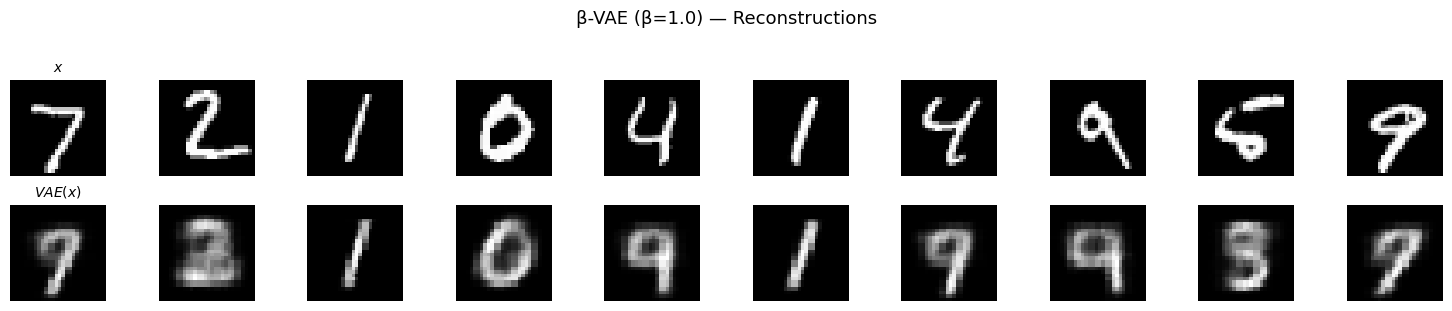

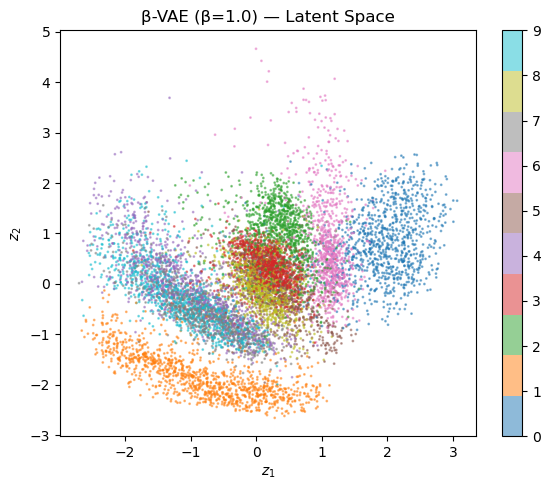

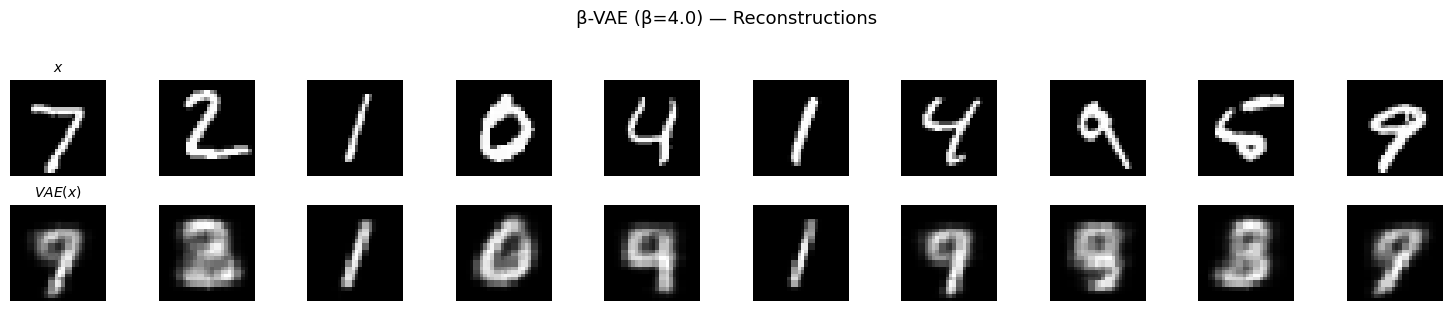

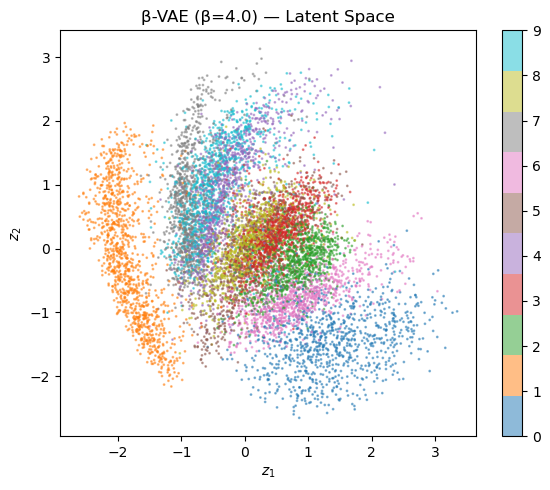

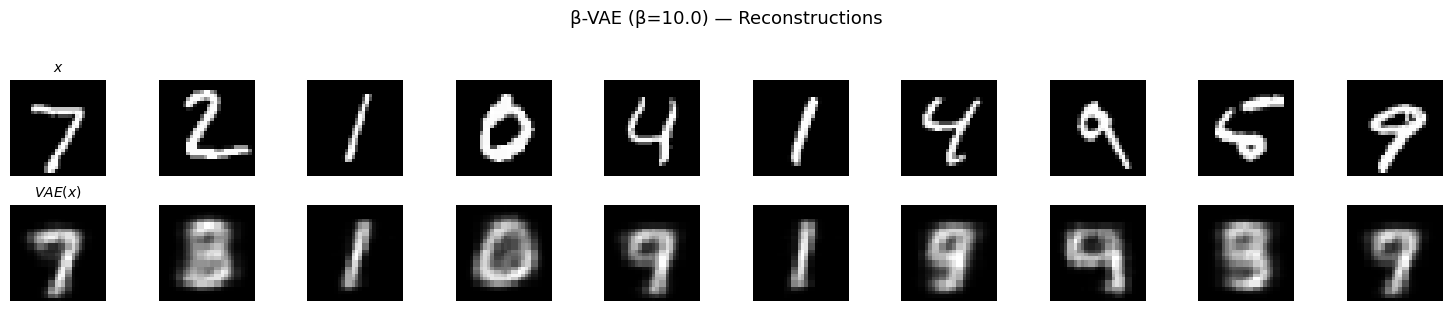

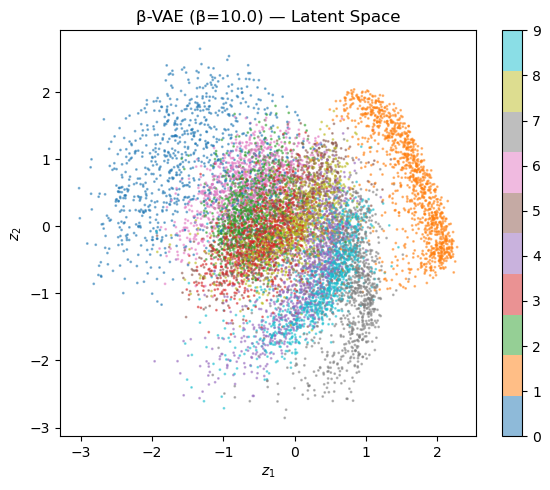

In [31]:
for b_val in betas:
    show_reconstructions(beta_models[b_val], test_loader, title=f"β-VAE (β={b_val}) — Reconstructions")
    show_latent_space(beta_models[b_val], test_loader, title=f"β-VAE (β={b_val}) — Latent Space")

Vary one latent dimension at a time to inspect disentanglement.

In [32]:
def show_latent_traversal(model, dim_to_traverse=0, n_steps=10, z_range=(-3, 3), title="Traversal"):
    model.eval()
    with torch.no_grad():
        z = torch.zeros(n_steps, latent_dim).to(device)
        z[:, dim_to_traverse] = torch.linspace(z_range[0], z_range[1], n_steps)
        samples = model.decoder(z)

    fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 1.2, 1.5))
    for i in range(n_steps):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")
    fig.suptitle(f"{title} — dim {dim_to_traverse}", fontsize=11, y=1.05)
    plt.tight_layout()
    plt.show()

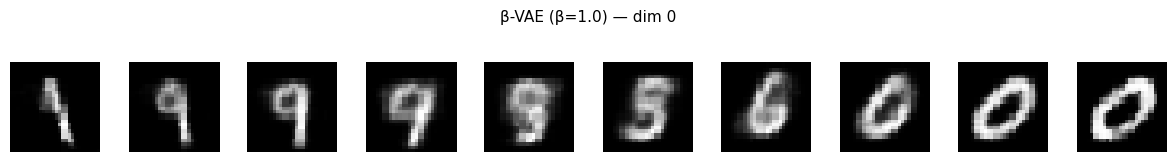

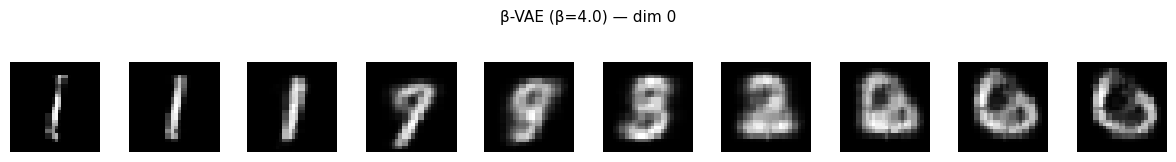

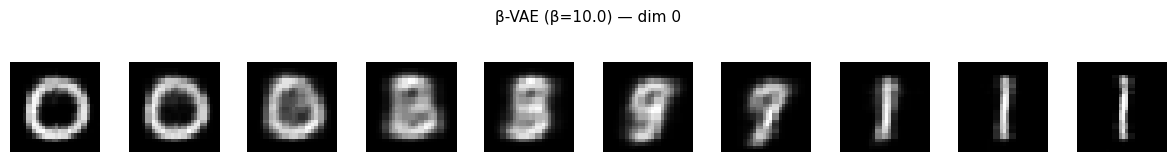

In [33]:
for b_val in betas:
    show_latent_traversal(beta_models[b_val], dim_to_traverse=0, title=f"β-VAE (β={b_val})")

---
## 3. Conditional VAE (CVAE)

The CVAE extends the VAE by conditioning both the encoder and the decoder on an additional observed variable $\mathbf{y}$ (e.g., a class label). The modified ELBO becomes:

$$
\mathcal{L}_{\mathrm{CVAE}}(\theta,\phi;\mathbf{x},\mathbf{y})
\;=\;
\mathbb{E}_{q_\phi(\mathbf{z}\mid\mathbf{x},\mathbf{y})}\!\bigl[\log p_\theta(\mathbf{x}\mid\mathbf{z},\mathbf{y})\bigr]
\;-\;
\mathrm{KL}\!\bigl(q_\phi(\mathbf{z}\mid\mathbf{x},\mathbf{y})\;\|\;p_\theta(\mathbf{z}\mid\mathbf{y})\bigr)
$$

Note that the prior itself can be conditioned on $\mathbf{y}$: $p_\theta(\mathbf{z}\mid\mathbf{y})$. In the simplest implementation, one uses an unconditional prior $p(\mathbf{z})=\mathcal{N}(\mathbf{0},\mathbf{I})$ and simply concatenates the one-hot label to both encoder and decoder inputs. At test time, providing a target label enables class-specific generation.

**What to implement.** Concatenate one-hot encoded labels to the encoder and decoder inputs. At test time, sample $\mathbf{z}\sim p(\mathbf{z})$ and provide a target label to generate class-specific samples.

**References.**
- Sohn, K., Lee, H., & Yan, X. (2015). *Learning Structured Output Representation using Deep Conditional Generative Models.* NeurIPS, pp. 3483–3491. [papers.nips.cc/paper/5775](https://papers.nips.cc/paper/5775-learning-structured-output-representation-using-deep-conditional-generative-models)
- Kingma, Diederik P., Danilo J. Rezende, Shakir Mohamed, and Max Welling. (2014) *Semi-Supervised Learning with Deep Generative Models*. [NeurIPS 2014](https://proceedings.neurips.cc/paper_files/paper/2014/file/6d42b1217a6996997ead5a8398c1f944-Paper.pdf)


In [ ]:
class CVAE(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        latent_dim: int,
        num_classes: int
      ):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.encoder = None
        self.decoder = None

    def sample(self, num_samples):
        pass

    def sample_conditional(self, labels):
        pass

    def forward(self, x, y):
        mu, logvar = None, None
        x_hat = None
        return x_hat, mu, logvar


def train_cvae(model, train_loader, epochs, lr):
    history = {"Total": [], "Rec": [], "KL": []}
    return history

print("Training Conditional VAE...")
cvae = CVAE(input_dim=INPUT_DIM, hidden_dim=hidden_dim,
            latent_dim=latent_dim, num_classes=NUM_CLASSES)
cvae = cvae.to(device)
cvae_history = train_cvae(cvae, train_loader, epochs=epochs, lr=lr)

In [ ]:
plot_losses(cvae_history, "CVAE — Training Loss Components")
show_samples(cvae, title="CVAE — Unconditional Samples")
show_latent_space(cvae, test_loader, title="CVAE — Latent Space")

In [ ]:
def show_conditional_samples(model: CVAE, n: int = 10, title: str = "Samples"):
    """Generate and display samples from the prior. Supports VAE and CVAE."""
    model.eval()

    labels = torch.randint(0, model.num_classes, (n,)).to(device)
    with torch.no_grad():
        samples = model.sample_conditional(labels)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.2, 1.5))
    for i in range(n):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"Class {labels[i].item()}")


    fig.suptitle(title, fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

show_conditional_samples(cvae)

---
## 4. KL Annealing / Cyclical Annealing

When the decoder is powerful enough to model the data on its own, the KL term can collapse to zero early in training — the encoder outputs the prior regardless of the input.

**Monotonic KL annealing** addresses this by introducing a time-dependent weight $\beta(t)$ that starts at 0 and linearly increases to 1:

$$
\mathcal{L}(t)
\;=\;
\mathbb{E}_{q_\phi(\mathbf{z}\mid\mathbf{x})}\!\bigl[\log p_\theta(\mathbf{x}\mid\mathbf{z})\bigr]
\;-\;
\beta(t)\;\mathrm{KL}\!\bigl(q_\phi(\mathbf{z}\mid\mathbf{x})\;\|\;p(\mathbf{z})\bigr),
\quad
\beta(t)=\frac{t}{T},
$$

where $T$ is the total number of training steps and $t\in\{1,\ldots,T\}$ is the current iteration.

**Cyclical annealing** repeats this schedule $M$ times over training. In each cycle, beta ramps from 0 to 1 over a fraction $R$ of the cycle, then stays at 1 for the remainder:

$$
\beta(t)=\min\!\Bigl(\frac{\tau(t)}{R},\;1\Bigr),
\qquad
\tau(t) = \frac{t \bmod \lceil T/M\rceil}{\lceil T/M\rceil}
$$

where $T$ is the total number of training steps, $M$ is the number of cycles, and $R\in(0,1]$ controls what fraction of each cycle is spent ramping.

**What to implement.** Keep the architecture identical. Implement a scheduler for $\beta(t)$. Compare constant $\beta=1$, monotonic annealing, and cyclical annealing ($M=4$, $R=0.5$). Monitor the KL term and reconstruction loss across training.

**References.**
- Bowman, S. R. et al. (2016). *Generating Sentences from a Continuous Space.* CoNLL, pp. 10–21. [aclanthology.org/K16-1002](https://aclanthology.org/K16-1002/)
- Fu, H. et al. (2019). *Cyclical Annealing Schedule: A Simple Approach to Mitigating KL Vanishing.* NAACL. [arXiv:1903.10145](https://arxiv.org/abs/1903.10145)

In [ ]:
def train_vae_annealing(model, train_loader, schedule="cyclical",
                         n_cycle=4, ratio=0.5, epochs=50, lr=1e-3):

    history = {"Total": [], "Rec": [], "KL": [], "beta": []}
    return history

schedules = ["constant", "monotonic", "cyclical"]
anneal_histories = {}
anneal_models = {}

for sched in schedules:
    print(f"\nTraining VAE with {sched} schedule...")
    model = VAE(input_dim=INPUT_DIM, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
    history = train_vae_annealing(model, train_loader, schedule=sched, epochs=epochs, lr=lr)
    anneal_histories[sched] = history
    anneal_models[sched] = model

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

# loss and kl plots
for sched in schedules:
    axes[0].plot(anneal_histories[sched]["Total"], label=sched)
    axes[1].plot(anneal_histories[sched]["KL"], label=sched)
axes[0].set_title("Total Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title("KL Divergence"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
# beta schedule plots
axes[2].plot(anneal_histories["constant"]["beta"], alpha=0.8)
axes[2].plot(anneal_histories["monotonic"]["beta"], alpha=0.8)
axes[2].plot(anneal_histories["cyclical"]["beta"], alpha=0.8)
axes[2].set_title("$beta$ schedule")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("beta")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for sched in schedules:
    show_reconstructions(anneal_models[sched], test_loader, title=f"Reconstruction - KL Annealing ({sched})")
    show_samples(anneal_models[sched], title=f"Sampling - KL Annealing ({sched})")

---
## 5. MMD-VAE (InfoVAE)

The InfoVAE framework identifies a fundamental tension in the standard ELBO: improving the bound can degrade the quality of the approximate posterior (the "information preference" problem). As a practical alternative, the MMD-VAE replaces the per-sample KL regularizer with the **Maximum Mean Discrepancy** (MMD) between the *aggregate* posterior $q_\phi(\mathbf{z})=\mathbb{E}_{p_{\mathrm{data}}(\mathbf{x})}[q_\phi(\mathbf{z}\mid\mathbf{x})]$ and the prior $p(\mathbf{z})$:

$$
\mathcal{L}_{\mathrm{MMD}}(\theta,\phi)
\;=\;
\mathbb{E}_{p_{\mathrm{data}}(\mathbf{x})}\mathbb{E}_{q_\phi(\mathbf{z}\mid\mathbf{x})}\!\bigl[\log p_\theta(\mathbf{x}\mid\mathbf{z})\bigr]
\;-\;
\lambda\;\mathrm{MMD}\!\bigl(q_\phi(\mathbf{z})\;\|\;p(\mathbf{z})\bigr)
$$

Given samples $\{\mathbf{z}_i\}_{i=1}^n \sim q_\phi(\mathbf{z})$ and $\{\tilde{\mathbf{z}}_j\}_{j=1}^n \sim p(\mathbf{z})$, the squared MMD with a kernel $k$ (typically a Gaussian RBF) is estimated as:

$$
\widehat{\mathrm{MMD}}^2
\;=\;
\frac{1}{n^2}\!\sum_{i,i'}k(\mathbf{z}_i,\mathbf{z}_{i'})
\;-\;
\frac{2}{n^2}\!\sum_{i,j}k(\mathbf{z}_i,\tilde{\mathbf{z}}_j)
\;+\;
\frac{1}{n^2}\!\sum_{j,j'}k(\tilde{\mathbf{z}}_j,\tilde{\mathbf{z}}_{j'})
$$

**What to implement.** Replace the KL divergence term with an MMD penalty computed using a Gaussian RBF kernel $k(\mathbf{z},\mathbf{z}')=\exp\!\bigl(-\|\mathbf{z}-\mathbf{z}'\|^2/(2\sigma^2)\bigr)$. Compare reconstructions and latent space structure against the standard VAE.

**Reference.** Zhao, S., Song, J., & Ermon, S. (2019). *InfoVAE: Balancing Learning and Inference in Variational Autoencoders.* AAAI, pp. 5885–5892. [arXiv:1706.02262](https://arxiv.org/abs/1706.02262)

In [ ]:
def compute_kernel(x, y):
    pass


def compute_mmd(z, z_prior):
    pass

def train_mmd_vae(model, train_loader, lam=100.0, epochs=50, lr=1e-3):
    history = {"Total": [], "Rec": [], "MMD": []}
    return history

print("Training MMD-VAE...")
mmd_vae = VAE(input_dim=INPUT_DIM, hidden_dim=hidden_dim, latent_dim=latent_dim)
mmd_vae = mmd_vae.to(device)
mmd_history = train_mmd_vae(mmd_vae, train_loader, epochs=epochs, lr=lr)

In [ ]:
plot_losses(mmd_history, "MMD-VAE — Training Loss Components")
show_reconstructions(mmd_vae, test_loader, title="MMD-VAE — Reconstructions")
show_samples(mmd_vae, title="MMD-VAE — Samples from Prior")
show_latent_space(mmd_vae, test_loader, title="MMD-VAE — Latent Space")